1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [2]:
# Download the Telco Customer Churn dataset from its raw URL (no Kaggle library needed).
import os
import urllib.request

DATA_DIR = "data"
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
DATA_PATH = os.path.join(DATA_DIR, "Telco-Customer-Churn.csv")

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)


In [3]:

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA) & Preprocessing

Clean data types, drop identifiers, encode the target and categoricals, and check class balance.

In [4]:
# TotalCharges is stored as text and is blank for brand-new customers (tenure == 0).
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with blank TotalCharges:", df["TotalCharges"].isna().sum())
print(df.loc[df["TotalCharges"].isna(), "tenure"].unique())

# Those customers have not been billed yet -> 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

Rows with blank TotalCharges: 11
[0]


In [5]:
# customerID has no predictive value; the target becomes a 0/1 integer.
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,0.27
std,24.56,30.09,2266.79,0.44
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,0.00
50%,29.00,70.35,1394.55,0.00
75%,55.00,89.85,3786.60,1.00
max,72.00,118.75,8684.80,1.00


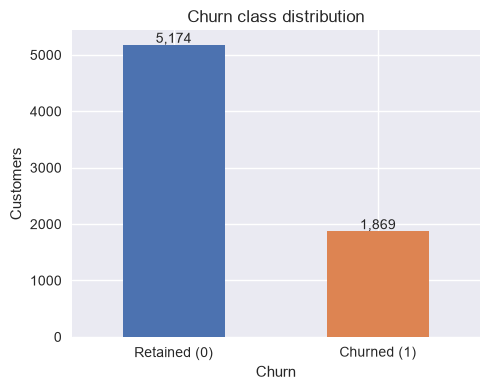

Churn rate: 26.5%  (roughly 27/73 -> use stratified split and class_weight)


In [6]:
# Visualise class imbalance to decide whether rebalancing is needed.
churn_counts = df["Churn"].value_counts().sort_index()

ax = churn_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"], figsize=(5, 4))
ax.set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Customers")
ax.set_title("Churn class distribution")
for i, v in enumerate(churn_counts):
    ax.text(i, v + 40, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Churn'].mean():.1%}  (roughly 27/73 -> use stratified split and class_weight)")

In [7]:
# One-hot encode the remaining categorical columns; cast the resulting flags to int.
df_encoded = pd.get_dummies(df, drop_first=True)
bool_cols = df_encoded.select_dtypes("bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 3. Data Splitting & Scaling

Separate features from target, hold out a stratified test set, and scale the continuous
features using statistics learned from the training set only.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3), " Test churn rate:", round(y_test.mean(), 3))

Train: (5634, 30)  Test: (1409, 30)
Train churn rate: 0.265  Test churn rate: 0.265


In [9]:
# Scale only the continuous features; fit on train, then apply to both splits (no leakage).
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe().round(3)

,tenure,MonthlyCharges,TotalCharges
count,5634.000,5634.000,5634.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-1.322,-1.544,-1.009
25%,-0.956,-0.971,-0.832
50%,-0.142,0.185,-0.397
75%,0.916,0.832,0.674
max,1.608,1.786,2.802


## 4. Model Training & Baseline Comparison

Train three baseline classifiers on the processed training set.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: fitted on {X_train.shape[0]} rows, {X_train.shape[1]} features")

Logistic Regression: fitted on 5634 rows, 30 features
Decision Tree: fitted on 5634 rows, 30 features


Random Forest: fitted on 5634 rows, 30 features


## 5. Evaluation & Feature Importance Analysis

Compare the models on precision, recall, F1 and ROC-AUC (accuracy alone is misleading at a
26.5% churn rate), then inspect the strongest churn drivers.

In [11]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, y_pred, output_dict=True)
    rows.append(
        {
            "Model": name,
            "Accuracy": rep["accuracy"],
            "Precision (churn)": rep["1"]["precision"],
            "Recall (churn)": rep["1"]["recall"],
            "F1 (churn)": rep["1"]["f1-score"],
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    )

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision (churn),Recall (churn),F1 (churn),ROC-AUC
Model,,,,,
Logistic Regression,0.806,0.659,0.559,0.605,0.842
Decision Tree,0.725,0.482,0.479,0.481,0.646
Random Forest,0.789,0.629,0.503,0.559,0.824


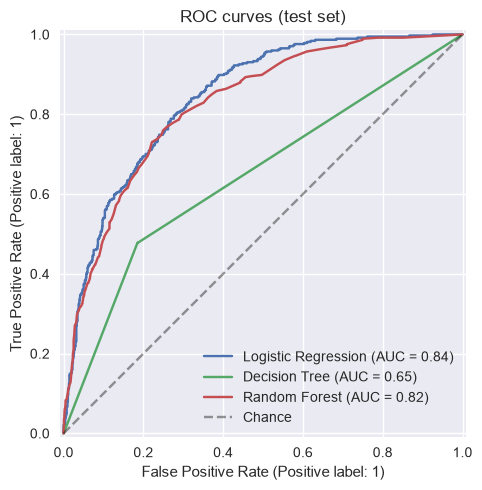

In [12]:
# ROC curves for all three models.
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax.set_title("ROC curves (test set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

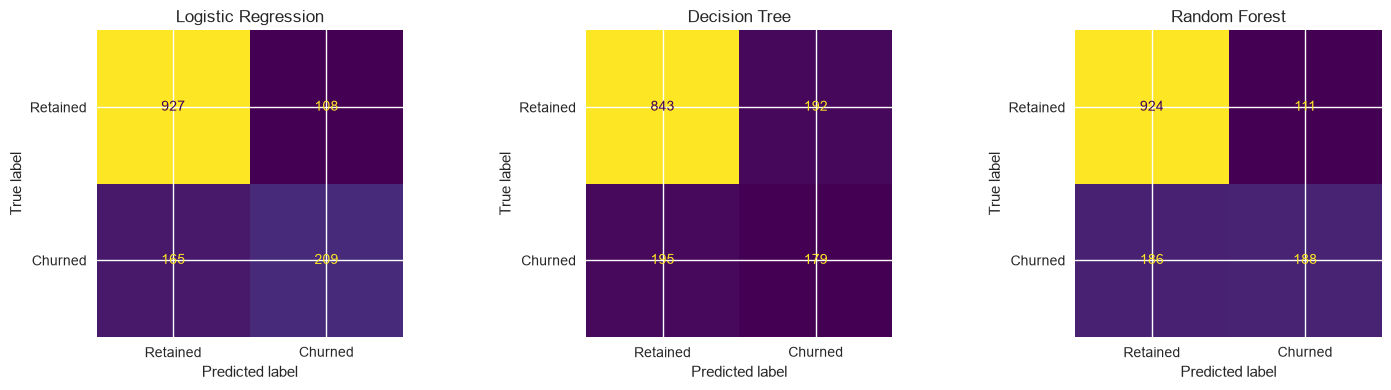

In [13]:
# Confusion matrices side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=ax, colorbar=False, display_labels=["Retained", "Churned"]
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

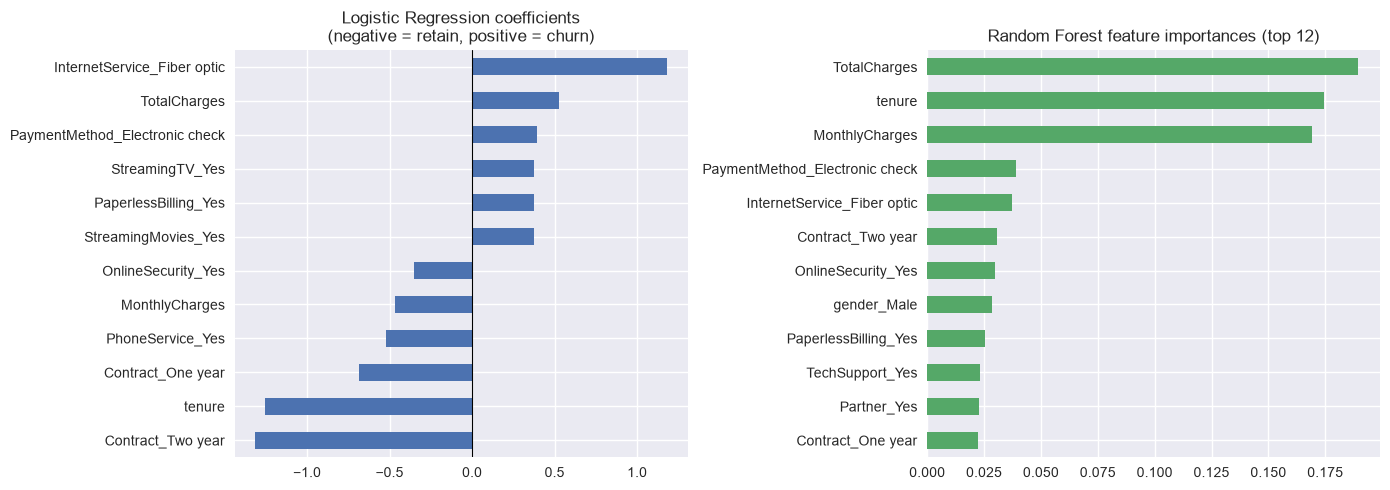

Strongest churn signals (LR): ['InternetService_Fiber optic', 'TotalCharges', 'PaymentMethod_Electronic check', 'StreamingTV_Yes', 'PaperlessBilling_Yes']
Strongest retention signals (LR): ['Contract_Two year', 'tenure', 'Contract_One year', 'PhoneService_Yes', 'MonthlyCharges']


In [14]:
# Top churn drivers: signed Logistic Regression coefficients and Random Forest importances.
lr_coef = pd.Series(models["Logistic Regression"].coef_[0], index=X_train.columns).sort_values()
rf_imp = pd.Series(
    models["Random Forest"].feature_importances_, index=X_train.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.concat([lr_coef.head(6), lr_coef.tail(6)]).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title("Logistic Regression coefficients\n(negative = retain, positive = churn)")

rf_imp.head(12).iloc[::-1].plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest feature importances (top 12)")
plt.tight_layout()
plt.show()

print("Strongest churn signals (LR):", list(lr_coef.tail(5).index[::-1]))
print("Strongest retention signals (LR):", list(lr_coef.head(5).index))